# Topic 3.1 - Matplotlib 基础简介

## 1. Matplotlib 包简介

Matplotlib 是一个主要用于创建静态可视化图表的 Python 库

- 它提供了一个类似于 MATLAB 的绘图界面，适合用于生成各种类型的图表，如折线图、散点图、柱状图、饼图等
- 虽然 Matplotlib 也支持动态图，但是应用较少，因为有其他更强大的库（如 Plotly 和 Bokeh）是专门用于做动态图表的
- 这些动态图表库我们这个系列课程就不涉及了，大家可以根据自己的需求去学习

Matplotlib 的核心模块是 `pyplot`，它提供了一组函数来简化绘图过程，使用户能够快速创建图表

- 也就是说，我们通常直接使用 `matplotlib.pyplot` 来进行绘图，行规代码是 `import matplotlib.pyplot as plt`
- 而 Matplotlib 还有其他一些子模块和工具，可以帮助我们进行更复杂的绘图任务，但是使用场景相对较少

我们这里先导入一下 Matplotlib 包，然后绘制一个简单的折线图：

In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df1 = pd.DataFrame({
    'A': [random.randint(1, 100) for _ in range(10)],
    'B': [random.randint(1, 100) for _ in range(10)]
}, index=pd.date_range('2023-01-01', periods=10))

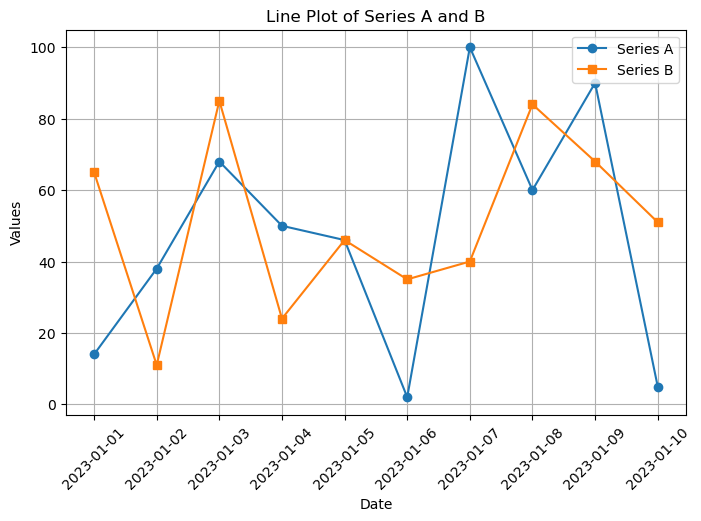

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(df1.index, df1['A'], marker='o', label='Series A')
plt.plot(df1.index, df1['B'], marker='s', label='Series B')
plt.xticks(rotation=45)
plt.title('Line Plot of Series A and B')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()

## 2. Matplotlib 的工作逻辑

通过上面我们的示例代码，大家可以发现，Matplotlib 的代码和我们以前写过的代码风格有些不同：

- 整段绘图的代码是从上到下 `plt.` 的方式一行行地写下来的，通过多次调用 `plt` 下的不同函数才完成一次绘图
- 这是因为 Matplotlib 采用了一种状态机（state machine）的工作逻辑
- 简单理解就是它会记录当前的绘图状态，然后根据我们调用的函数来更新这个状态，最终生成图表
- 最终展示出来的效果，类似于 PhotoShop 里一层层图层叠加的效果

## 3. Matplotlib 的中文显示问题

在使用 Matplotlib 绘图时，默认是不支持中文显示的，如果直接使用中文作为标题或者标签，会出现警告提示，图像显示里会有乱码：

In [4]:
df2 = pd.DataFrame({
    "A": [random.randint(1, 100) for _ in range(10)],
    "B": [random.randint(1, 100) for _ in range(10)]
}, index=pd.date_range("2023-01-01", periods=10))

/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340

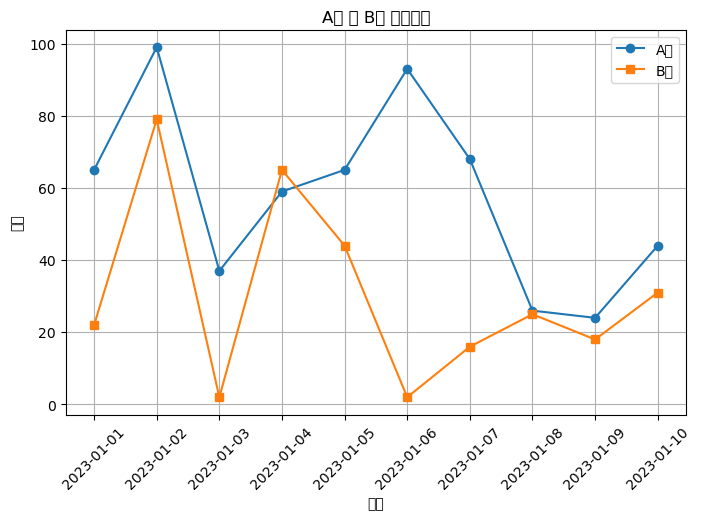

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(df2.index, df2['A'], marker='o', label='A列')
plt.plot(df2.index, df2['B'], marker='s', label='B列')
plt.xticks(rotation=45)
plt.title('A列 和 B列 的折线图')
plt.xlabel('日期')
plt.ylabel('数值')
plt.legend()
plt.grid(True)
plt.show()

因此，要解决这个问题，则需要添加字体的配置代码，最好是在导入 Matplotlib 包之后就立刻添加：

- Windows 用户可以使用 `SimHei` 字体，也就是黑体
- Mac 用户可以使用 `STHeiti` 字体，也就是华文黑体

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['STHeiti']   # 指定默认字体
plt.rcParams['axes.unicode_minus'] = False      # 解决负号显示问题

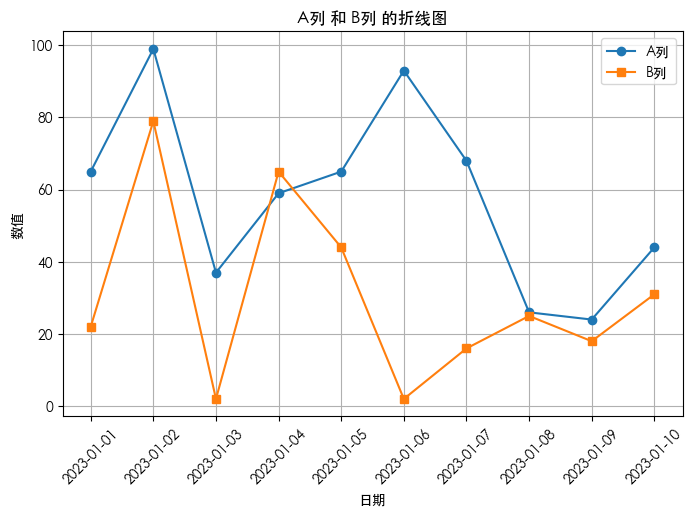

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(df2.index, df2['A'], marker='o', label='A列')
plt.plot(df2.index, df2['B'], marker='s', label='B列')
plt.xticks(rotation=45)
plt.title('A列 和 B列 的折线图')
plt.xlabel('日期')
plt.ylabel('数值')
plt.legend()
plt.grid(True)
plt.show()